In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn. cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', None)

In [26]:
df = pd.read_csv("marketing_campaign.csv", sep="\t")
print(f"Raw data shape: {df.shape}")
df.head()

Raw data shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [27]:
print("missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print("Year_Birth range:", df["Year_Birth"].min(), "-", df["Year_Birth"].max())
print("Income range:", df["Income"].min(), "-", df["Income"].max())
print()
print("Marital_Status values:")
print(df["Marital_Status"].value_counts())

missing values per column:
Income    24
dtype: int64

Year_Birth range: 1893 - 1996
Income range: 1730.0 - 666666.0

Marital_Status values:
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


In [28]:
# Drop unnecessary columns
df = df.drop(columns=["Z_CostContact", "Z_Revenue", "ID"])

before = len(df)
df = df[df["Year_Birth"] >= 1930].reset_index(drop=True)
print(f"Dropped {before - len(df)} rows with implausible Year_Birth values.")

Dropped 3 rows with implausible Year_Birth values.


In [29]:
# Capping outliers in the Income column
df["Income"] = df["Income"].fillna(df["Income"].median())

q1, q3 = df["Income"].quantile(0.25), df["Income"].quantile(0.75)
iqr = q3 - q1
income_upper_bound = q3 + 1.5 * iqr
n_capped = (df["Income"] > income_upper_bound).sum()
df["Income"] = df["Income"].clip(upper=income_upper_bound)
print(f"Capped {n_capped} Income outlier(s) at {income_upper_bound:.0f} in Income column.")

Capped 8 Income outlier(s) at 117418 in Income column.


In [30]:
# Replace values in the Marital_Status column
df["Marital_status"] = df["Marital_Status"].replace({"Alone": "Single", "Absurd": "Single", "YOLO": "Single"})
df["Marital_status"].value_counts()

Marital_status
Married     864
Together    579
Single      486
Divorced    231
Widow        77
Name: count, dtype: int64

In [31]:
# Create new features
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y")

df["Age"] = df["Dt_Customer"].dt.year - df["Year_Birth"]

reference_date = df["Dt_Customer"].max()
df["Customer_Tenure"] = (reference_date - df["Dt_Customer"]).dt.days

spend_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
df["Total_Spend"] = df[spend_cols].sum(axis=1)

purchase_cols = ["NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]
df["Total_Purchases"] = df[purchase_cols].sum(axis=1)

campaign_cols = ["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5"]
df["Total_Campaigns_Accepted"] = df[campaign_cols].sum(axis=1)

df["Children"] = df["Kidhome"] + df["Teenhome"]

new_features = ["Age", "Customer_Tenure", "Total_Spend", "Total_Purchases", "Total_Campaigns_Accepted", "Children"]
df[new_features].describe()

,Age,Customer_Tenure,Total_Spend,Total_Purchases,Total_Campaigns_Accepted,Children
count,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000
mean,44.126062,353.790344,605.743406,14.870809,0.297720,0.950827
std,11.739008,202.137961,601.840466,7.676593,0.678615,0.752037
min,16.000000,0.000000,5.000000,0.000000,0.000000,0.000000
25%,36.000000,181.000000,69.000000,8.000000,0.000000,0.000000
50%,43.000000,356.000000,396.000000,15.000000,0.000000,1.000000
75%,54.000000,529.000000,1045.000000,21.000000,0.000000,1.000000
max,73.000000,699.000000,2525.000000,44.000000,4.000000,3.000000


In [45]:
education_order = ["Basic", "2n Cycle", "Graduation", "Master", "PhD"]
ordinal_encoder = OrdinalEncoder(categories=[education_order])
df["Education_Encoded"] = ordinal_encoder.fit_transform(df[["Education"]])

marital_dummies = pd.get_dummies(df["Marital_status"], prefix="Marital", drop_first=True)

base_features = [
    "Age", "Income", "Kidhome", "Teenhome", "Children", "Recency",
    "Customer_Tenure", "Total_Spend", "Total_Purchases", "Total_Campaigns_Accepted", "NumWebVisitsMonth", "Complain",
    "Education_Encoded"
] 

X = pd.concat([df[base_features], marital_dummies], axis=1)

print(f"Clustering features shape: {X.shape[1]} columns")
X.head()

Clustering features shape: 17 columns


,Age,Income,Kidhome,Teenhome,Children,Recency,Customer_Tenure,Total_Spend,Total_Purchases,Total_Campaigns_Accepted,NumWebVisitsMonth,Complain,Education_Encoded,Marital_Married,Marital_Single,Marital_Together,Marital_Widow
0,55,58138.0,0,0,0,58,663,1617,25,0,7,0,2.0,False,True,False,False
1,60,46344.0,1,1,2,38,113,27,6,0,5,0,2.0,False,True,False,False
2,48,71613.0,0,0,0,26,312,776,21,0,4,0,2.0,False,False,True,False
3,30,26646.0,1,0,1,26,139,53,8,0,6,0,2.0,False,False,True,False
4,33,58293.0,1,0,1,94,161,422,19,0,5,0,4.0,True,False,False,False


In [46]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance ratio by components: {pca.explained_variance_ratio_}")
print(f"Total explained variance by 2 components: {pca.explained_variance_ratio_.sum()*100:.1f}%")

Explained variance ratio by components: [0.23109699 0.11449003]
Total explained variance by 2 components: 34.6%


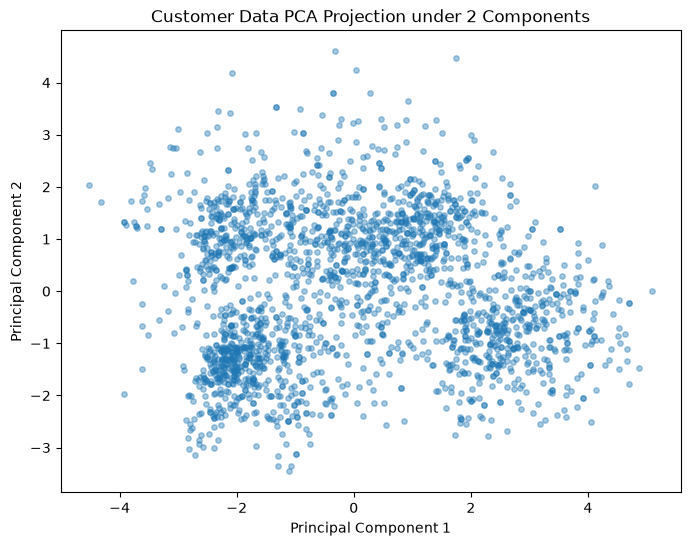

In [47]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.4, s=15)
plt.title("Customer Data PCA Projection under 2 Components")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [48]:
k_range = range(2, 9)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, labels))
    
    
for k, inertia, silhouette in zip(k_range, inertias, silhouette_scores):
    print(f"k={k}: Inertia={inertia:.2f}, Silhouette Score={silhouette:.4f}")

k=2: Inertia=6471.19, Silhouette Score=0.4463
k=3: Inertia=4173.95, Silhouette Score=0.4363
k=4: Inertia=2618.93, Silhouette Score=0.4786
k=5: Inertia=2218.78, Silhouette Score=0.4458
k=6: Inertia=1932.79, Silhouette Score=0.4261
k=7: Inertia=1694.04, Silhouette Score=0.4036
k=8: Inertia=1509.41, Silhouette Score=0.3805
